In [12]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit import ControlledGate
import matplotlib.pyplot as plt
import math

In [18]:
# The aim of the assignment is to simulate the BB84 key distribution protocol.

# This notebook is for a simulation of the protocol with an attacker, to demonstrate that the attacker can be detected.

# Eavesdropping (for my reference): Eve will be the attacker. Firstly, she will intercept qubits from Alice,
# Measure them (guessing the basis) and sends new qubits to Bob based on her measurements.
# When Eve guesses the wrong basis, she disturbs the qubit, creating errors in the final key
# Alice and Bob detects the high error rate. Expected error rate with attacker: ~25%, without is ~0%.

In [19]:
# ============================================================
# QUANTUM RANDOM NUMBER GENERATION
# ============================================================

def generate_quantum_random_bits(n):
    """
    Generate n random bits using quantum measurements.
    """
    qc = QuantumCircuit(n, n)

    for i in range(n):
        qc.h(i)

    qc.measure(range(n), range(n))

    backend = BasicSimulator()
    compiled = transpile(qc, backend)
    job = backend.run(compiled, shots=1)
    result = job.result()
    counts = result.get_counts()

    bitstring = list(counts.keys())[0]
    return [int(bit) for bit in reversed(bitstring)]

In [20]:
# ============================================================
# BB84 PROTOCOL FUNCTIONS
# ============================================================

def alice_prepare_qubit(bit, basis):
    """
    Alice prepares a qubit.
    """
    qc = QuantumCircuit(1, 1)

    if bit == 1:
        qc.x(0)

    if basis == 1:
        qc.h(0)

    return qc


def eve_intercept_qubit(qc, eve_basis):
    """
    Eve intercepts and measures the qubit, then resends it.
    This is the 'intercept-resend' attack.
    """
    # Eve measures in her chosen basis
    if eve_basis == 1:
        qc.h(0)

    qc.measure(0, 0)

    # Get Eve's measurement result
    backend = BasicSimulator()
    compiled = transpile(qc, backend)
    job = backend.run(compiled, shots=1)
    result = job.result()
    counts = result.get_counts()
    eve_result = int(list(counts.keys())[0])

    # Eve prepares a NEW qubit based on her measurement
    new_qc = QuantumCircuit(1, 1)
    if eve_result == 1:
        new_qc.x(0)
    if eve_basis == 1:
        new_qc.h(0)

    return new_qc, eve_result


def bob_measure_qubit(qc, basis):
    """
    Bob measures the qubit.
    """
    if basis == 1:
        qc.h(0)

    qc.measure(0, 0)

    backend = BasicSimulator()
    compiled = transpile(qc, backend)
    job = backend.run(compiled, shots=1)
    result = job.result()
    counts = result.get_counts()

    return int(list(counts.keys())[0])


def create_shared_key(alice_bits, alice_bases, bob_bases, bob_results):
    """
    Basis reconciliation - keep matching bases only.
    """
    alice_key = []
    bob_key = []
    matching_positions = []

    for i in range(len(alice_bits)):
        if alice_bases[i] == bob_bases[i]:
            alice_key.append(alice_bits[i])
            bob_key.append(bob_results[i])
            matching_positions.append(i)

    return alice_key, bob_key, matching_positions

In [21]:
# ============================================================
# VISUALIZATION FUNCTIONS
# ============================================================

def show_transmission_with_eve(alice_bits, alice_bases, eve_bases, eve_results,
                                bob_bases, bob_results, matching_positions):
    """
    Show the complete transmission including Eve's interference.
    """
    print("\n" + "="*70)
    print("BB84 TRANSMISSION WITH EVE")
    print("="*70)

    print("\nPosition:      ", end="")
    for i in range(len(alice_bits)):
        print(f"{i:3d}", end=" ")

    print("\nAlice sent:    ", end="")
    for bit in alice_bits:
        print(f"  {bit}", end=" ")

    print("\nAlice's basis: ", end="")
    for basis in alice_bases:
        print(f"  {'X' if basis == 1 else 'Z'}", end=" ")

    print("\n" + "-"*70)
    print("EVE INTERCEPTS:")
    print("-"*70)

    print("Eve's basis:   ", end="")
    for basis in eve_bases:
        print(f"  {'X' if basis == 1 else 'Z'}", end=" ")

    print("\nEve measured:  ", end="")
    for result in eve_results:
        print(f"  {result}", end=" ")

    print("\n" + "-"*70)
    print("BOB RECEIVES:")
    print("-"*70)

    print("Bob's basis:   ", end="")
    for basis in bob_bases:
        print(f"  {'X' if basis == 1 else 'Z'}", end=" ")

    print("\nBob measured:  ", end="")
    for result in bob_results:
        print(f"  {result}", end=" ")

    print("\nBases match?   ", end="")
    for i in range(len(alice_bits)):
        if i in matching_positions:
            print("  ✓", end=" ")
        else:
            print("  ✗", end=" ")
    print("\n")


def show_key_with_errors(alice_key, bob_key):
    """
    Show the keys and highlight errors caused by Eve.
    """
    print("="*70)
    print("FINAL KEYS (After Basis Reconciliation)")
    print("="*70)

    print("\nAlice's key: ", end="")
    for bit in alice_key:
        print(bit, end=" ")

    print("\nBob's key:   ", end="")
    for bit in bob_key:
        print(bit, end=" ")

    print("\nErrors?      ", end="")
    error_positions = []
    for i in range(len(alice_key)):
        if alice_key[i] != bob_key[i]:
            print("✗", end=" ")
            error_positions.append(i)
        else:
            print("✓", end=" ")

    errors = len(error_positions)
    error_rate = (errors / len(alice_key) * 100) if alice_key else 0

    print(f"\n\nError count: {errors}/{len(alice_key)}")
    print(f"Error rate (QBER): {error_rate:.2f}%")

    if error_rate > 5:
        print("\n HIGH ERROR RATE DETECTED!")
        print("   Eavesdropping suspected - ABORT and restart!")
    else:
        print("\n✓ Low error rate - communication appears secure")

    print("\n" + "="*70)


def create_visualizations_with_eve(n_bits, alice_key, bob_key, matching_positions):
    """
    Create visualizations showing Eve's impact.
    """
    # Calculate statistics
    errors = sum(1 for i in range(len(alice_key)) if alice_key[i] != bob_key[i])
    correct = len(alice_key) - errors
    error_rate = (errors / len(alice_key) * 100) if alice_key else 0

    matching = len(matching_positions)
    discarded = n_bits - matching

    # Create charts
    reconciliation = {
        'Kept': matching,
        'Discarded': discarded
    }

    accuracy = {
        'Correct bits': correct,
        'Errors (Eve caused)': errors
    }

    # Comparison with theory
    theory_vs_actual = {
        f'Expected (25%)': 25,
        f'Actual ({error_rate:.1f}%)': error_rate
    }

    print("\nVISUALIZATIONS\n")
    display(plot_histogram(reconciliation, title='1. Basis Reconciliation', color='skyblue'))
    display(plot_histogram(accuracy, title='2. Error Detection (QBER)', color='coral'))
    display(plot_histogram(theory_vs_actual, title='3. Error Rate: Theory vs Actual', color='lightgreen'))

In [22]:
# ============================================================
# RUN BB84 WITH EAVESDROPPER
# ============================================================

def run_bb84_with_eve(n_bits=20):
    """
    Execute BB84 protocol with Eve intercepting.
    """
    print("\n" + "="*70)
    print("BB84 WITH EAVESDROPPER (EVE)")
    print("="*70)
    print(f"\nSending {n_bits} qubits (Eve is listening!)...\n")

    # Generate random choices for Alice, Bob, AND Eve
    alice_bits = generate_quantum_random_bits(n_bits)
    alice_bases = generate_quantum_random_bits(n_bits)
    bob_bases = generate_quantum_random_bits(n_bits)
    eve_bases = generate_quantum_random_bits(n_bits)  # Eve's random choices

    # Transmission with Eve's interference
    bob_results = []
    eve_results = []

    for i in range(n_bits):
        # Alice prepares qubit
        qc = alice_prepare_qubit(alice_bits[i], alice_bases[i])

        # EVE INTERCEPTS!
        qc, eve_result = eve_intercept_qubit(qc, eve_bases[i])
        eve_results.append(eve_result)

        # Bob measures the (possibly disturbed) qubit
        result = bob_measure_qubit(qc, bob_bases[i])
        bob_results.append(result)

    # Basis reconciliation
    alice_key, bob_key, matching_positions = create_shared_key(
        alice_bits, alice_bases, bob_bases, bob_results
    )

    # Show results
    show_transmission_with_eve(alice_bits, alice_bases, eve_bases, eve_results,
                                bob_bases, bob_results, matching_positions)
    show_key_with_errors(alice_key, bob_key)

    # Statistics
    print("STATISTICS")
    print("="*70)
    print(f"Qubits sent: {n_bits}")
    print(f"Matching bases: {len(matching_positions)}")
    print(f"Final key length: {len(alice_key)} bits")

    errors = sum(1 for i in range(len(alice_key)) if alice_key[i] != bob_key[i])
    error_rate = (errors / len(alice_key) * 100) if alice_key else 0
    print(f"\nQuantum Bit Error Rate (QBER): {error_rate:.2f}%")
    print(f"Theoretical expected: ~25%")
    print("="*70)

    # Visualizations
    create_visualizations_with_eve(n_bits, alice_key, bob_key, matching_positions)

    return alice_key, bob_key, error_rate


BB84 WITH EAVESDROPPER (EVE)

Sending 20 qubits (Eve is listening!)...


BB84 TRANSMISSION WITH EVE

Position:        0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18  19 
Alice sent:      0   1   1   1   0   0   1   0   1   1   0   1   1   1   0   1   1   0   1   1 
Alice's basis:   Z   Z   Z   Z   X   X   X   X   X   X   X   X   Z   Z   Z   Z   Z   X   Z   Z 
----------------------------------------------------------------------
EVE INTERCEPTS:
----------------------------------------------------------------------
Eve's basis:     Z   X   Z   X   Z   X   Z   Z   X   Z   X   X   Z   X   X   X   X   X   Z   Z 
Eve measured:    0   1   1   0   0   0   1   1   1   0   0   1   1   1   1   0   0   0   1   1 
----------------------------------------------------------------------
BOB RECEIVES:
----------------------------------------------------------------------
Bob's basis:     Z   Z   Z   X   Z   Z   Z   Z   Z   X   X   Z   Z   X   X   Z   X   X   Z   Z 
Bob meas

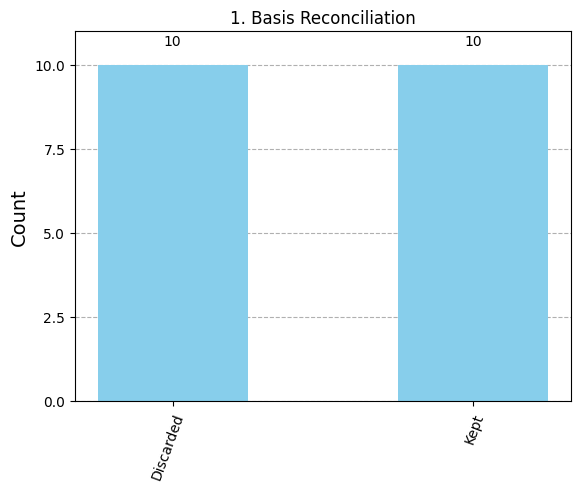

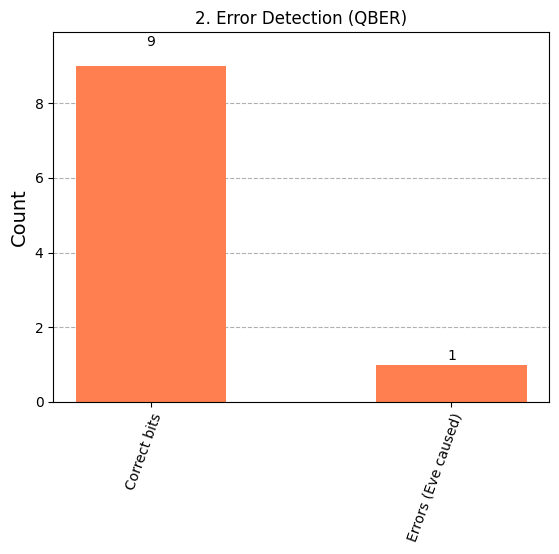

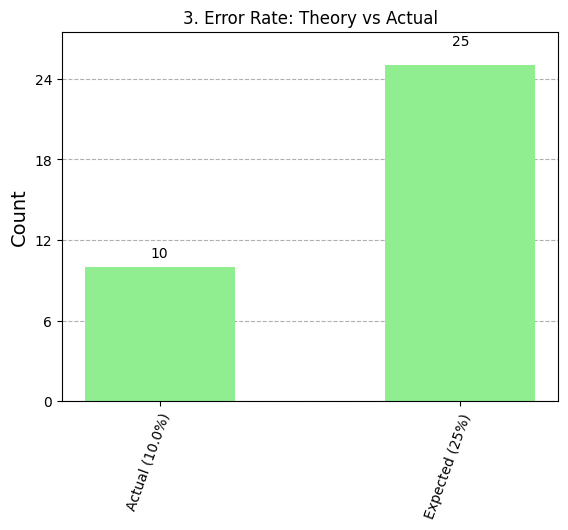

In [23]:
# Run BB84 with eavesdropper
alice_key, bob_key, error_rate = run_bb84_with_eve(n_bits=20)


RUNNING MULTIPLE TRIALS FOR STATISTICAL VALIDATION

Running 10 trials...

RESULTS:
  Trials completed: 10
  Average QBER: 27.40%
  Range: 0.0% - 45.5%
  Theoretical expected: 25%

✓ Results confirm ~25% error rate when Eve is present!



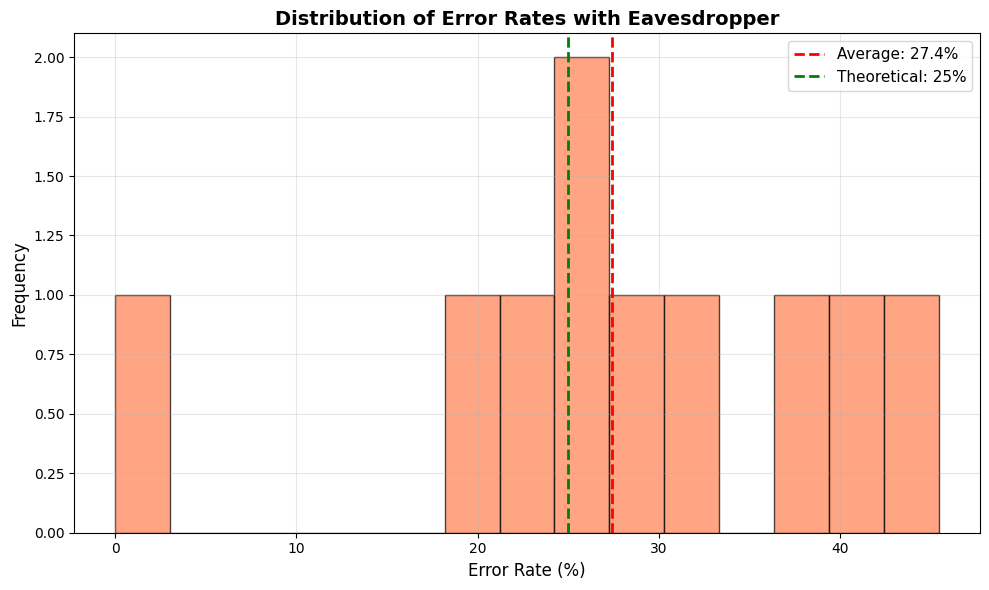

In [15]:
# ============================================================
# STATISTICAL ANALYSIS - Multiple Trials
# ============================================================

print("\n" + "="*70)
print("RUNNING MULTIPLE TRIALS FOR STATISTICAL VALIDATION")
print("="*70)

n_trials = 10
error_rates = []

print(f"\nRunning {n_trials} trials...")

for trial in range(n_trials):
    # Run silently
    alice_bits = generate_quantum_random_bits(24)
    alice_bases = generate_quantum_random_bits(24)
    bob_bases = generate_quantum_random_bits(24)
    eve_bases = generate_quantum_random_bits(24)

    bob_results = []
    eve_results = []

    for i in range(24):
        qc = alice_prepare_qubit(alice_bits[i], alice_bases[i])
        qc, eve_result = eve_intercept_qubit(qc, eve_bases[i])
        eve_results.append(eve_result)
        result = bob_measure_qubit(qc, bob_bases[i])
        bob_results.append(result)

    alice_key, bob_key, _ = create_shared_key(
        alice_bits, alice_bases, bob_bases, bob_results
    )

    if alice_key:
        errors = sum(1 for i in range(len(alice_key)) if alice_key[i] != bob_key[i])
        error_rate = (errors / len(alice_key)) * 100
        error_rates.append(error_rate)

# Calculate statistics
avg_error = sum(error_rates) / len(error_rates)
min_error = min(error_rates)
max_error = max(error_rates)

print(f"\nRESULTS:")
print(f"  Trials completed: {len(error_rates)}")
print(f"  Average QBER: {avg_error:.2f}%")
print(f"  Range: {min_error:.1f}% - {max_error:.1f}%")
print(f"  Theoretical expected: 25%")
print(f"\n✓ Results confirm ~25% error rate when Eve is present!\n")

# Plot distribution
plt.figure(figsize=(10, 6))
plt.hist(error_rates, bins=15, edgecolor='black', alpha=0.7, color='coral')
plt.axvline(avg_error, color='red', linestyle='--', linewidth=2,
            label=f'Average: {avg_error:.1f}%')
plt.axvline(25, color='green', linestyle='--', linewidth=2,
            label='Theoretical: 25%')
plt.xlabel('Error Rate (%)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Error Rates with Eavesdropper', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "="*70)